# 

In [1]:
import hanoi
import scipy.integrate as integrate
import scipy.stats as stats
import numpy as np
from itertools import product
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
# Make meshgrid
V00, V11 = np.meshgrid(10 ** np.linspace(-2,1,16), 10 ** np.linspace(-2,1,16))

In [7]:
V = np.column_stack([V00.ravel(), V11.ravel()])

In [22]:
def integrand(z, v):
    #return np.exp(-z**2 / (2 * v)) / (1 + np.exp(-z))
    return hanoi.fit_sigmoid([0], [1], np.array(z).reshape(1,1)) * stats.norm.pdf(z, loc = 0, scale = np.sqrt(v))

In [23]:
def w_g(v):
    return integrate.quad(integrand, -np.inf, np.inf, args=(v))

In [24]:
??hanoi.sim_reproduction

Signature: hanoi.sim_reproduction(popsize, genotype, fitness)
Source:   
def sim_reproduction(popsize, genotype, fitness):
    """
    Simulates reproduction.

    Arguments:
        popsize :  int N representing population size
        genotype : 2D np.ndarray of (L, N) representing genotype of parents.
        fitness :  1D np.ndarray of N representing fitness of parents.

    Returns: A tuple (genotype_next, n_offspring)
        genotype_next : 2D np.ndarray of (L, N) representing genotype of the offspring
        n_offspring :  Number of offspring.
                        Should be a 1D np.ndarray of length N and the sum should be 2N.
                        n_offspring[i] holds the number of offspring of parent individual i.
    """
    # number of offspring per genotype of each genotype
    n_loci = genotype.shape[0]
    if fitness.sum() == 0:
        genotype_next = np.full((n_loci, popsize), np.nan)
        n_offspring = np.zeros(popsize, dtype = int)
        #raise RuntimeErro

In [25]:
p_00 = 0.70**2
p_01 = 2 * 0.30 * 0.7
p_11 = 0.3**2
delta_p_1 = np.empty((V.shape[0],1))
for i, (v00, v11) in enumerate(V):
    v01 = (v00 + v11) / 2
    w_00 = w_g(v00)[0]
    w_01 = w_g(v01)[0]
    w_11 = w_g(v11)[0]
    w_all = p_00 * w_00 + p_01 * w_01 + p_11 * w_11
    p_1_next = (p_01 * w_01 / 2 + p_11 * w_11) / w_all
    delta_p_1[i, 0] = p_1_next - (p_01/2 + p_11)

In [21]:
delta_p_1

array([[ 0.00000000e+00],
       [ 5.55111512e-17],
       [-8.88178420e-16],
       [ 6.66133815e-16],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 5.55111512e-17],
       [-1.11022302e-16],
       [ 5.55111512e-17],
       [-1.66533454e-16],
       [ 0.00000000e+00],
       [ 5.55111512e-17],
       [ 5.55111512e-17],
       [ 5.55111512e-17],
       [ 0.00000000e+00],
       [ 5.55111512e-17],
       [ 0.00000000e+00],
       [ 5.55111512e-17],
       [-8.32667268e-16],
       [-4.38538095e-15],
       [ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 5.55111512e-17],
       [-1.66533454e-16],
       [ 1.11022302e-16],
       [-1.66533454e-16],
       [-5.55111512e-17],
       [ 0.00000000e+00],
       [ 5.55111512e-17],
       [ 5.55111512e-17],
       [ 0.00000000e+00],
       [ 5.55111512e-17],
       [ 5.55111512e-16],
       [ 6.66133815e-16],
       [ 5.55111512e-17],
       [ 3.88578059e-16],
       [ 4.44089210e-16],
       [ 4.99600361e-16],
       [ 4.9

In [61]:
?hanoi.sim_generations


Signature:
hanoi.sim_generations(
    n_gen,
    mut_effect,
    genotype,
    mut_rate,
    mean_0,
    varcov_0,
    fit_func,
    seed=None,
    record=True,
    **kwargs,
)
Docstring:
Simulates multiple generations.

Arguments:
    n_gen :      Number of generations to simulate. 
                 n_gen = 0 runs simulation until mutations at all loci are fixed in the population.
    mut_effect : hanoi.MutEffect representing the mutation effect.
    genotype :   2D np.ndarray of (L, N) representing the initial genotype table.
    mut_rate :   A float representing mutation rate per locus per generation.
    mean_0 :     2D np.ndarray of (n, N) representing expectation of n traits for a genotype of 0000...
    varcov_0 :   2D np.ndarray of (n, n) representing baseline variance-covariance matrix for a genotype of 0000....
    fit_func :   str representing the fitness function. 
                 Should be one of "fit_neutral", "fit_gaus", "fit_multimodal", "fit_step".
    seed :       in

Simulate 1 generation with sigmoid

In [198]:
#bs = np.array([0.25, 1, 4])
#M0 = np.array([0, 0.9, 1, 1.1, 2])
#M1 = np.array([0, 0.9, 1, 1.1, 2])
bs = np.array([4])
M0 = np.array([1.0])
M1 = np.array([1.0])
V0 = 10 ** np.linspace(-2, 1, 16)
V1 = 10 ** np.linspace(-2, 1, 16)
parcombs = np.array(list(product(bs, M0, M1, V0, V1)))

In [324]:
G = np.repeat([0,1,2], [250, 500, 250]).astype(float).reshape((1,1000))


out = []
for i, (b, m0, m1, v0, v1) in enumerate(parcombs):
    #print(f"{i} {i/len(parcombs):.2f} {m0} {m1} {v0} {v1}")
    M_m = np.array([[m1 - m0]])
    M_v = np.array([[v1 - v0]])
    z_ref = np.array([m0])
    c_ref = np.array([[v0]])
    M = hanoi.MutEffect(mean = M_m, var = M_v, cov=np.array([[]]))
    res = hanoi.run_replicates(n_reps = 100, 
                               max_workers = 8,
                               n_gen = 1000, 
                               genotype = G, 
                               mut_effect = M, 
                               record = False, 
                               mut_rate = 0.0, 
                               mean_0 = z_ref,
                               varcov_0 = c_ref, 
                               fit_func = "fit_sigmoid",
                               a = [1],
                               b = [b]
                         )
    out.append([[b, m0, m1, v0, v1, res[j][0], res[j][1].allele_freqs_next()[0,0]] for j in range(len(res))])
out = np.array(out).reshape(-1, np.array(out).shape[2])
out_df = pd.DataFrame(out, columns = ["b", "m0", "m1", "v0", "v1", "n_gen", "allele_fixed"])
out_df = out_df.astype({"n_gen": "int64", "allele_fixed": np.float64})

KeyboardInterrupt: 

In [312]:
out_df

,b,m0,m1,v0,v1,n_gen,allele_fixed
0,4.0,1.0,1.0,0.01,0.01,10,0.435
1,4.0,1.0,1.0,0.01,0.01,10,0.600
2,4.0,1.0,1.0,0.01,0.01,10,0.595
3,4.0,1.0,1.0,0.01,0.01,10,0.450
4,4.0,1.0,1.0,0.01,0.01,10,0.415
...,...,...,...,...,...,...,...
25595,4.0,1.0,1.0,10.00,10.00,10,0.385
25596,4.0,1.0,1.0,10.00,10.00,10,0.535
25597,4.0,1.0,1.0,10.00,10.00,10,0.605
25598,4.0,1.0,1.0,10.00,10.00,10,0.355


In [313]:
d_smr = out_df.groupby(['b', 'm0', 'm1', 'v0', 'v1'], as_index=False)['allele_fixed'].mean()

In [314]:
d_smr.head()

,b,m0,m1,v0,v1,allele_fixed
0,4.0,1.0,1.0,0.01,0.010000,0.49300
1,4.0,1.0,1.0,0.01,0.015849,0.51690
2,4.0,1.0,1.0,0.01,0.025119,0.50920
3,4.0,1.0,1.0,0.01,0.039811,0.49850
4,4.0,1.0,1.0,0.01,0.063096,0.50815


In [315]:
d_smr["log_v0"] = np.log10(d_smr["v0"])
d_smr["log_v1"] = np.log10(d_smr["v1"])

In [316]:
v0_all = np.sort(d_smr["v0"].unique())
v1_all = np.sort(d_smr["v1"].unique())
def heatmap_panel(data, **kwargs):
    table = data.pivot_table(index="v1", columns="v0", values="allele_fixed")
    sns.heatmap(table, cmap="viridis", cbar=True, **kwargs)

In [317]:
row_order_m = sorted(d_smr["m1"].unique(), reverse=True)  # top row = largest m1
col_order_m = sorted(d_smr["m0"].unique())

In [322]:
def heatmap_panel(data, **kwargs):
    # pivot inside the panel
    table = data.pivot(index="v1", columns="v0", values="allele_fixed")
    sns.heatmap(table, cmap="coolwarm", vmin=0.45, vmax=0.55, cbar=False, ax=plt.gca())
    ax = plt.gca()
    ax.invert_yaxis()

    # Get current tick positions
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()

    # Set labels only for every 5th tick
    ax.set_xticklabels([f"$10^{{{int(np.log10(table.columns[int(t)]) )}}}$" if i % 5 == 0 else ""
                        for i, t in enumerate(xticks)], rotation=0)
    ax.set_yticklabels([f"$10^{{{int(np.log10(table.index[int(t)]))}}}$" if i % 5 == 0 else ""
                        for i, t in enumerate(yticks)])
    # Hide axis labels inside panel
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)

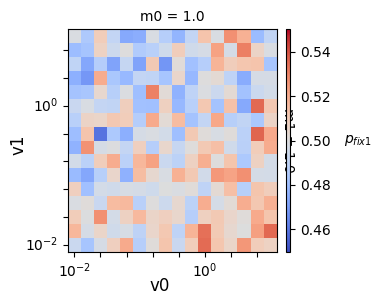

In [323]:
g = sns.FacetGrid(d_smr, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
g.map_dataframe(heatmap_panel)
g.fig.supxlabel("v0", x = 0.5, y = 0)
g.fig.supylabel('v1', y = 0.5, x = 0)


# Add a colorbar next to the last panel
# Compute position of the last panel
last_ax = g.axes[-1, -1]  # last row, last column
pos = last_ax.get_position()  # Bbox

# Create a new Axes for the colorbar: slightly thinner than a panel
cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])
# Use the same colormap and normalization
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0.45, vmax=0.55))
#sm = plt.cm.ScalarMappable(cmap="coolwarm")
sm.set_array([])
#g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label = "$p_{fix1}$")
cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label("$p_{fix1}$", rotation=0, labelpad=10, va='center', ha='left')


plt.show()

In [2]:
?hanoi.fit_gaus

Signature: hanoi.fit_gaus(sigma, z_opt, z)
Docstring:
Computes fitness based on a Gaussian fitness function.

Arguments:
    sigma: A scalar specifying SD around the peak
    z_opt: (n,) array specifying the coordinate of the peak in the n dimensional phenotypic space
    z:      (N, n) array representing n-dimensional phenotypes of N individuals.
Returns: (N,) array representing fitness of N individuals
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/fitness.py
Type:      function